<h1>Cubo Gelatinoso</h1>

<h4><i>Bruno Bini Camargo</i></h4>

#### *Pontos a melhorar*

- conclusão, seção de interação com IA
- fazer referências ABNT e citá-las pelo texto
- ler textos e melhorar

<h2>Introdução</h2>

A ciência dos materiais é um campo interdisciplinar de pesquisa que busca continuamente compreender a estabilidade termodinâmica de novos compostos através de propriedades fundamentais, tais como a energia de formação por átomo. Esse valor pode ser obtido através da Teoria do Funcional da Densidade (DFT), um método simulatório muito preciso, mas que, em termos computacionais, é caro e demorado para análises em larga escala.

Neste trabalho, utiliza-se um conjunto de dados sobre materiais de uma bateria de lítio [1] para prever a energia de formação por átomo (ou seja, esse será nosso target). A modelagem é realizada através do algoritmo $k$-Nearest Neighbors ($k$-NN), baseado na premissa que dados semelhantes ocupam regiões próximas no espaço de entrada. Assim, por meio da comparação dos atributos (que, nesse trabalho, serão: número de elementos, volume, energia por átomo, band gap, semicondutibilidade e densidade), serão previstas as energias de formação por átomo dos materiais tabelados.

O objetivo deste trabalho é construir e otimizar um modelo de regressão baseado em $k$-NN, avaliando o desempenho de $10$ combinações distintas de hiperparâmetros e variando o número de vizinhos ($k$) e as métricas de distância, para determinar a configuração da menor Raiz do Erro Quadrático Médio (RMSE).

<h2>Desenvolvimento</h2>

Vamos iniciar transformando os dados do ranking, que estão em uma planilha Excel, para o formato de Data Frame do Python, por meio do módulo pandas. 

De forma a lidar com uma amostra de dados, limitei meu estudo apenas a $200$ exemplos da planilha, escolhidos usando semente aleatória (SEED = $42$).

In [6]:
import pandas as pd

NOME_ARQUIVO = "lithium_battery_materials.csv"

df = pd.read_csv(NOME_ARQUIVO)

SEED = 42

amostra = df.sample(n=200, random_state=SEED)

amostra

,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements
74006,mp-756176,Li2CrS3,3,False,0.877879,0.518484,-0.868213,False,-0.634656,-0.128617,"['Cr', 'Li', 'S']"
41314,mp-1175222,Li7Mn4CoO12,4,True,-0.096333,0.104689,-0.280832,False,0.129678,-0.606860,"['Co', 'Li', 'Mn', 'O']"
17549,mp-1174116,Li5Co3O8,3,True,0.356561,0.353809,-0.868213,False,0.206353,-0.837061,"['Co', 'Li', 'O']"
14784,mp-756384,Li3Cr2Fe5O12,4,True,0.137866,-0.096644,-0.868213,False,0.399547,-0.580761,"['Cr', 'Fe', 'Li', 'O']"
15975,mp-769928,Li4NbV3O8,4,False,-0.524039,-0.133104,-0.868213,False,0.342545,-0.786479,"['Li', 'Nb', 'O', 'V']"
...,...,...,...,...,...,...,...,...,...,...,...
40476,mp-772719,Li6V3P8O29,4,False,-0.754540,-0.082719,-0.133766,False,-0.779805,2.124230,"['Li', 'O', 'P', 'V']"
78647,mp-766527,Li3Mn4(PO4)6,4,True,-0.488755,-0.108469,-0.578483,False,-0.387650,1.212833,"['Li', 'Mn', 'O', 'P']"
20248,mp-1175491,Li9Co7O16,3,True,0.368118,0.309486,-0.688241,False,0.311630,-0.406781,"['Co', 'Li', 'O']"
85905,mp-1176199,Li9Mn2Co5O16,4,True,0.173726,0.221432,-0.519914,False,0.279750,-0.406469,"['Co', 'Li', 'Mn', 'O']"


Antes de começar a modelagem dos dados, necessitamos tratar esses dados. 

Os atributos "contains_metal_transition" e "is_semiconductor" são categóricos booleanos, ou seja, possuem valores do tipo True/False (verdadeiro/falso). Como o algoritmo k-NN que vamos utilizar se baseia em cálculos de distância entre os pontos, precisaremos converter essas variáveis para outra representação.

Vamos adotar a representação binária numérica, sendo $1$ para verdadeiro e $0$ para falso. Assim, permitiremos que o modelo meça a proximidade dessas características físico-químicas de maneira quantitativa sem alterar o seu significado original.

In [7]:
mapa_bool = {
    False: 0, True: 1
}

amostra['contains_transition_metal'] = amostra['contains_transition_metal'].map(
    mapa_bool
)

amostra['is_semiconductor'] = amostra['is_semiconductor'].map(
    mapa_bool
)

Vamos separar as colunas da planilha que serão usadas como atributos (que chamarei de X) e a que será nosso *target* (que nomearei y).

In [8]:
ATRIBUTOS = ["n_elements",
             "contains_transition_metal",
             "volume",
             "energy_per_atom",
             "band_gap",
             "is_semiconductor",
             "density"
            ]

TARGET = ["formation_energy_per_atom"]

X = amostra[ATRIBUTOS]
y = amostra[TARGET]

In [9]:
X

,n_elements,contains_transition_metal,volume,energy_per_atom,band_gap,is_semiconductor,density
74006,3,0,-0.128617,0.518484,-0.868213,0,-0.634656
41314,4,1,-0.606860,0.104689,-0.280832,0,0.129678
17549,3,1,-0.837061,0.353809,-0.868213,0,0.206353
14784,4,1,-0.580761,-0.096644,-0.868213,0,0.399547
15975,4,0,-0.786479,-0.133104,-0.868213,0,0.342545
...,...,...,...,...,...,...,...
40476,4,0,2.124230,-0.082719,-0.133766,0,-0.779805
78647,4,1,1.212833,-0.108469,-0.578483,0,-0.387650
20248,3,1,-0.406781,0.309486,-0.688241,0,0.311630
85905,4,1,-0.406469,0.221432,-0.519914,0,0.279750


In [10]:
y

,formation_energy_per_atom
74006,0.877879
41314,-0.096333
17549,0.356561
14784,0.137866
15975,-0.524039
...,...
40476,-0.754540
78647,-0.488755
20248,0.368118
85905,0.173726


Vamos então separar a amostra em conjuntos independentes de treino ($90\%$) e teste ($10\%$) utilizando train_test_split com semente aleatória (SEED = $42$) para garantir a reprodutibilidade do experimento. 

In [12]:
from sklearn.model_selection import train_test_split

indices_treino, indices_teste = train_test_split(
    amostra.index, test_size=0.1, random_state=SEED
)

df_treino = amostra.loc[indices_treino]
df_teste = amostra.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1)
y_treino = df_treino.reindex(TARGET, axis=1)

X_teste = df_teste.reindex(ATRIBUTOS, axis=1)
y_teste = df_teste.reindex(TARGET, axis=1)

Abaixo, conseguimos conferir os conjuntos de treino dos atributos (X_treino) e do target (y_treino); e de teste dos atributos (X_teste) e do target (y_teste).

In [13]:
X_treino

,n_elements,contains_transition_metal,volume,energy_per_atom,band_gap,is_semiconductor,density
68065,4,0,-0.700546,-0.126804,0.066993,1,-0.761727
62311,4,1,-0.339192,0.497336,1.016011,1,-1.048984
12993,3,0,1.989587,0.428685,-0.701241,0,-1.114910
373,3,0,1.690016,0.145222,-0.816415,0,-0.884726
21842,2,0,-0.654873,-5.972728,-0.868213,0,2.140099
...,...,...,...,...,...,...,...
52477,3,0,-1.021306,1.410132,-0.868213,0,1.729359
30334,3,0,0.081927,0.033114,-0.868213,0,0.210753
1815,3,0,-1.039311,-8.588778,-0.868213,0,6.431613
5641,4,0,-0.742173,-1.535766,-0.868213,0,0.593351


In [14]:
X_teste

,n_elements,contains_transition_metal,volume,energy_per_atom,band_gap,is_semiconductor,density
81930,4,0,2.140458,-0.096349,-0.180080,0,-0.814473
41204,4,1,-0.633390,0.246548,-0.868213,0,0.263411
21702,4,0,1.225378,0.069366,-0.196939,0,-0.152558
2996,4,1,-0.501903,-0.018108,-0.394584,0,-0.101448
31436,4,0,0.648599,-0.085071,-0.580108,0,0.938086
8147,5,0,0.154592,0.256729,0.852425,1,-0.261206
58058,4,0,2.317339,-0.180447,-0.649443,0,-0.786847
2212,3,1,0.438728,-0.238265,-0.868213,0,0.165301
2683,3,1,-0.032777,-0.130425,-0.868213,0,0.378294
60687,5,1,-0.342437,-0.154112,0.955953,1,-0.304960


In [15]:
y_treino

,formation_energy_per_atom
68065,-0.523994
62311,-0.718807
12993,-1.176483
373,1.250700
21842,2.084300
...,...
52477,1.929994
30334,-0.120181
1815,1.665589
5641,-1.085891


In [17]:
y_teste

,formation_energy_per_atom
81930,-0.656516
41204,0.252644
21702,-0.440150
2996,-0.577058
31436,-0.165104
8147,0.090228
58058,-1.220671
2212,0.151187
2683,-0.038547
60687,-0.726404


Iniciando agora o modelo de $k$-NN, definimos que o número k de vizinhos será $3$. Ou seja, o modelo reconhecerá, para cada target, os $3$ vizinhos mais próximos. Ajustamos então o modelo usando exclusivamente os dados de X_treino e de y_treino.

Com os dados devidamente treinados, aplicamos o $k$-NN sobre os dados inéditos de teste (X_teste) para gerar as previsões da energia de formação por átomo (y_previsto). 

Para determinar a acurácia do modelo, calculamos a Raiz do Erro Quadrático Médio (RMSE), comparando os valores reais (y_teste) com os previstos. Escolhi o RMSE porque é uma ferramenta muito utilizada em problemas de regressão (como nesse caso), traz o valor para a escala real dos dados e por ser sensível a grandes erros, facilitando a identificação do erro na previsão.

In [19]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error

NUM_VIZINHOS = 3
modelo_knn = KNeighborsRegressor(n_neighbors=NUM_VIZINHOS)
modelo_knn.fit(X_treino, y_treino)

X_verdadeiro = X_teste
y_verdadeiro = y_teste

y_previsto = modelo_knn.predict(X_verdadeiro)

RMSE = root_mean_squared_error(y_verdadeiro, y_previsto)

print(f"O RMSE do modelo foi de{RMSE: .2f} eV.")

O RMSE do modelo foi de 0.64 eV.


É possível verificar que o RMSE foi de $0.64\text{ eV}$, o que significa que, em média, as previsões do modelo estão errando em $0.64\text{ eV}$, para mais ou para menos, em relação aos valores reais calculados via DFT.

Vamos analisar graficamente o modelo. Esse gráfico abaixo compara os valores reais do target (y_verdadeiro) e os previstos (y_previsto). A linha vermelha tracejada representa a linha de identidade (y = x), ou seja, o cenário ideal onde a previsão é exatamente igual ao valor real.

In [20]:
y_real = y_verdadeiro.values.ravel()
y_prev = y_previsto.ravel()

min_val = min(y_real.min(), y_prev.min())
max_val = max(y_real.max(), y_prev.max())

intervalo = [min_val * 0.95, max_val * 1.05]

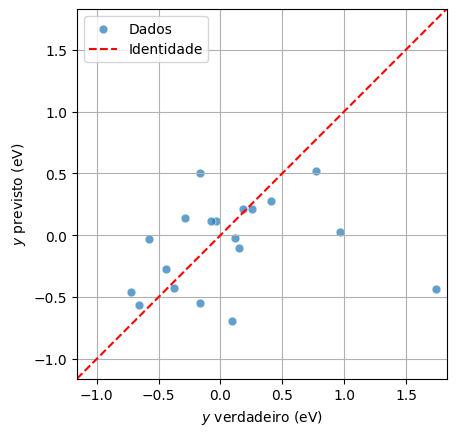

In [93]:
import seaborn as sns

eixo = sns.scatterplot(x=y_real, y=y_prev, label="Dados", alpha=0.7, s=40)
eixo.plot(intervalo, intervalo, "r--", label="Identidade", linewidth=1.5)

eixo.set(
    xlabel="$y$ verdadeiro (eV)",
    ylabel="$y$ previsto (eV)",
    xlim=intervalo,
    ylim=intervalo,
    aspect="equal",
)

eixo.grid(True)
eixo.legend();

Observando o gráfico, vemos que uma parte dos pontos acompanha o alinhamento da linha tracejada, o que mostra que o $k$-NN com $3$ vizinhos consegue capturar a tendência geral em alguns casos.

Porém, no canto inferior direito, há alguns erros graves, tais como um material cujo valor real é próximo de $1.75\text{ eV}$, mas o modelo previu um valor negativo em torno de $-0.1\text{ eV}$. Além disso, notamos uma dispersão considerável ao longo do centro do gráfico, com pontos bastante afastados da linha de identidade. Esses erros isolados são os responsáveis pelo nosso RMSE ter ficado em $0.64\text{ eV}$. Como essa métrica penaliza com mais força os erros muito distantes do alvo, esses pontos puxaram o erro total para cima. Fica claro que o modelo funciona, mas precisa de alguns ajustes. 

Por isso, agora vamos usar da normalização dos dados para tentar aproximar esses pontos da linha ideal.

<h3>Normalização dos dados</h3>

A normalização é um processo de transformação dos dados para uma determinada escala em comum. Há três tipos de normalização: padrão (StandardScaler), pelo máximo absoluto (MaxAbsScaler) e pelo mínimo e máximo (MinMaxScaler). 

Vamos começar pela normalização padrão, que altera a média dos dados para $0$ e o desvio padrão dos dados para $1$.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_treino_std = scaler_std.fit_transform(X_treino)
X_teste_std = scaler_std.transform(X_teste)

knn_std = KNeighborsRegressor(n_neighbors=NUM_VIZINHOS)
knn_std.fit(X_treino_std, y_treino.values.ravel())

y_previsto_std = knn_std.predict(X_teste_std)

RMSE_std = root_mean_squared_error(y_verdadeiro, y_previsto_std)

print(f"O RMSE do modelo foi de{RMSE_std: .2f} eV.")

O RMSE do modelo foi de 0.68 eV.


É perceptível que o RMSE do modelo com os dados normalizados aumentou $0.04\text{ eV}$ em comparação ao com os dados sem normalização.

Vamos então realizar a normalização pelo máximo absoluto, que faz com que todos os dados fiquem no intervalo de [-1, 1].

In [25]:
from sklearn.preprocessing import MaxAbsScaler

scaler_max = MaxAbsScaler()
X_treino_max = scaler_max.fit_transform(X_treino)
X_teste_max = scaler_max.transform(X_teste)

knn_max = KNeighborsRegressor(n_neighbors=NUM_VIZINHOS)
knn_max.fit(X_treino_max, y_treino.values.ravel())

y_previsto_max = knn_max.predict(X_teste_max)

RMSE_max = root_mean_squared_error(y_teste, y_previsto_max)

print(f"O RMSE do modelo foi de{RMSE_max: .2f} eV.")

O RMSE do modelo foi de 0.69 eV.


A escala pelo máximo absoluto manteve a tendência de queda de desempenho, elevando o RMSE para $0.69\text{ eV}$, indicando uma piora adicional de $0.01\text{ eV}$ em relação à normalização padrão.

Façamos a última normalização, pelo mínimo e máximo, que garante que os dados tenham valor mínimo de $0$ e valor máximo de $1$.

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_treino_minmax = scaler_minmax.fit_transform(X_treino)
X_teste_minmax = scaler_minmax.transform(X_teste)

knn_minmax = KNeighborsRegressor(n_neighbors=NUM_VIZINHOS)
knn_minmax.fit(X_treino_minmax, y_treino.values.ravel())

y_previsto_minmax = knn_minmax.predict(X_teste_minmax)

RMSE_minmax = root_mean_squared_error(y_teste, y_previsto_minmax)

print(f"O RMSE do modelo foi de{RMSE_minmax: .2f} eV.")

O RMSE do modelo foi de 0.70 eV.


Esta última normalização apresentou o pior resultado entre todas as abordagens, com o RMSE atingindo $0.70\text{ eV}$.

Graficamente, conseguimos ver a dispersão dos dados comparando o target real (tabelado) e o previsto pelo modelo nas quatro situações (sem normalização, normalização padrão, normalização pelo máximo absoluto, e normalização pelo mínimo e máximo):

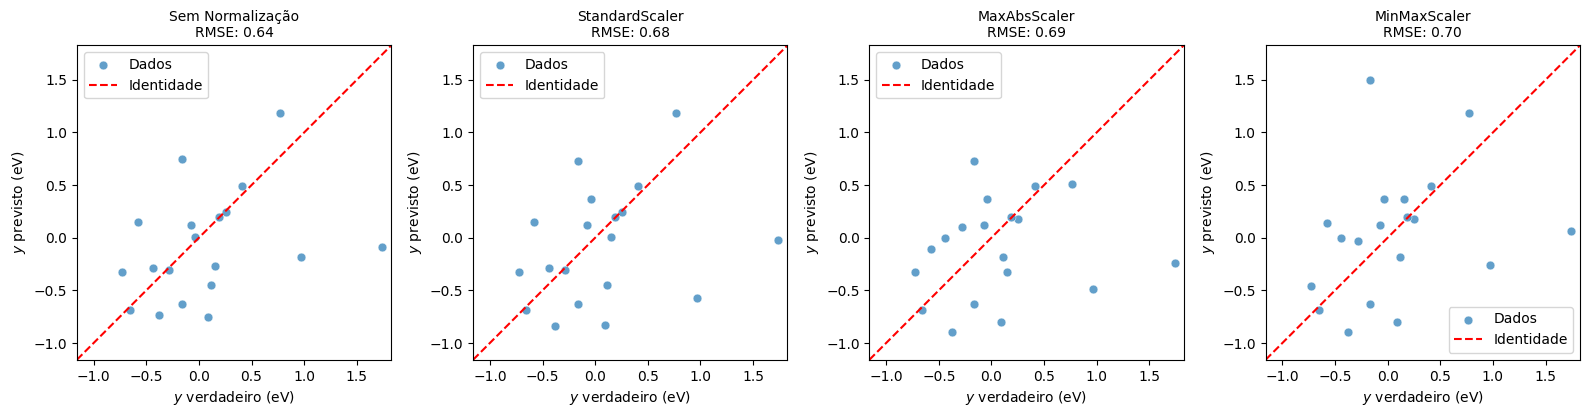

In [92]:
import matplotlib.pyplot as plt

modelos = [
    ("Sem Normalização", y_previsto, RMSE),
    ("StandardScaler", y_previsto_std, RMSE_std),
    ("MaxAbsScaler", y_previsto_max, RMSE_max),
    ("MinMaxScaler", y_previsto_minmax, RMSE_minmax),
]

fig, eixos = plt.subplots(1, 4, figsize=(16, 4))

for eixo, (titulo, y_pred, rmse) in zip(eixos, modelos):
    sns.scatterplot(
        x=y_real.ravel(), y=y_pred.ravel(), label="Dados", alpha=0.7, s=40, ax=eixo
    )
    eixo.plot(intervalo, intervalo, "r--", label="Identidade", linewidth=1.5)

    eixo.set(
        xlabel="$y$ verdadeiro (eV)",
        ylabel="$y$ previsto (eV)",
        xlim=intervalo,
        ylim=intervalo,
        aspect="equal",
    )
    eixo.set_title(f"{titulo}\nRMSE: {rmse:.2f}", fontsize=10)
    eixo.legend()

plt.tight_layout()
plt.show()

Observando o primeiro gráfico (sem normalização), nota-se uma concentração de pontos relativamente mais próxima da linha de identidade no intervalo central (entre $-0.5$ e $0.5\text{ eV}$). À medida que aplicamos as normalizações (padrão, pelo máximo absoluto, e pelo mínimo e máximo), os pontos sofrem um espalhamento vertical visivelmente maior. No caso do MinMaxScaler ($RMSE = 0.70\text{ eV}$), surge inclusive um ponto discrepante próximo do topo ($y \approx 1.5\text{ eV}$ para $y \approx -0.15\text{ eV}$), indicando uma predição fortemente penalizada.

Esse comportamento ocorre porque, ao igualarmos a variação de todos os atributos, retiramos o peso natural das variáveis brutas que possuíam maior magnitude e que, fisicamente, eram as mais determinantes para o target. Com isso, atributos principais e secundários ganharam a mesma relevância no cálculo da distância geométrica, inserindo ruído nas predições. 

Assim, concluímos que, para esse caso, manter os dados em sua escala original é a escolha mais adequada, de forma a garantir a menor dispersão e o menor RMSE.

<h3>Hiperparâmetros</h3>

Frente aos modelos com normalização de dados, o $k$-NN com $k = 3$ era um bom modelo. Entretanto, ainda mantém um RMSE de $0.64\text{ eV}$, indicando a existência de desvios. 

Vamos então agora testar outras combinações de hiperparâmetros para tentar corrigir esses desvios e aproximar os dados da reta identidade. Defini uma lista com $10$ combinações distintas de hiperparâmetros, variando o número de vizinhos ($k = 1, 3, 5, 7$ e $15$) e a métrica de distância ($p = 1$ para distância de Manhattan, $p = 2$ para distância Euclidiana e $p = 3$ para distância $L_3$).

Para contextualizar a escolha dos valores de $p$, vale resumir brevemente como cada uma dessas métricas opera. A distância de Manhattan ($p=1$) calcula a distância somando os valores absolutos das diferenças em cada coordenada. Ela representa o deslocamento estritamente ao longo dos eixos cartesianos, como o trajeto de um carro seguindo a grade de quadras de uma cidade. Já a distância Euclidiana ($p=2$) mede a menor linha reta direta entre dois pontos no espaço, por meio da raiz quadrada da soma das diferenças ao quadrado de cada dimensão. Por último, a distância $L_3$ ($p=3$) determina a distância pela raiz cúbica da soma das diferenças elevadas ao cubo, penalizando grandes discrepâncias em dimensões individuais de forma mais rigorosa do que a métrica euclidiana. Com essas três abordagens geométricas integradas à busca de hiperparâmetros, podemos avaliar qual forma de medir distâncias se adapta melhor ao comportamento dos nossos dados.

Em seguida, construí um laço de repetição que percorre cada um desses conjuntos. Para cada configuração, o $k$-NN é treinado com os dados de treino, são geradas as previsões nos dados de teste e é calculado o RMSE correspondente. 

Todos os resultados estão organizados na tabela abaixo, ordenada do menor para o maior erro, permitindo identificar qual combinação de hiperparâmetros entrega o melhor desempenho para o nosso problema.

In [91]:
combinacoes = [
    # Distância Manhattan (p = 1)
    {"n_neighbors": 1, "p": 1},
    {"n_neighbors": 3, "p": 1},
    {"n_neighbors": 5, "p": 1},
    {"n_neighbors": 7, "p": 1},
    {"n_neighbors": 15, "p": 1},
    # Distância Euclidiana (p = 2)
    {"n_neighbors": 1, "p": 2},
    {"n_neighbors": 3, "p": 2},
    {"n_neighbors": 5, "p": 2},
    {"n_neighbors": 7, "p": 2},
    {"n_neighbors": 15, "p": 2},
    # Distância L3 (p = 3)
    {"n_neighbors": 1, "p": 3},
    {"n_neighbors": 3, "p": 3},
    {"n_neighbors": 5, "p": 3},
    {"n_neighbors": 7, "p": 3},
    {"n_neighbors": 15, "p": 3},
   
]

resultados = []

for i, params in enumerate(combinacoes, start=1):
    knn = KNeighborsRegressor(**params)

    knn.fit(X_treino, y_treino.values.ravel())

    y_prev = knn.predict(X_teste)
    rmse = root_mean_squared_error(y_teste, y_prev)

    resultados.append(
        {
            "Conjunto": f"Hiperparâmetro {i}",
            "k (vizinhos)": params["n_neighbors"],
            "Métrica": "Manhattan" if params["p"] == 1 else("Euclidiana" if params["p"] == 2  else "L3") ,
            "RMSE (eV)": rmse,
        }
    )

df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE (eV)")

print(
    df_resultados.to_string(
        index=False,
        justify = "center",
        col_space = 15, 
    )
)

     Conjunto       k (vizinhos)      Métrica         RMSE (eV)  
 Hiperparâmetro 5        15           Manhattan       0.587375   
 Hiperparâmetro 2         3           Manhattan       0.598759   
Hiperparâmetro 10        15          Euclidiana       0.619277   
 Hiperparâmetro 4         7           Manhattan       0.619597   
 Hiperparâmetro 3         5           Manhattan       0.629540   
 Hiperparâmetro 9         7          Euclidiana       0.633149   
Hiperparâmetro 15        15                  L3       0.635335   
 Hiperparâmetro 7         3          Euclidiana       0.640105   
Hiperparâmetro 12         3                  L3       0.644500   
 Hiperparâmetro 1         1           Manhattan       0.657952   
Hiperparâmetro 14         7                  L3       0.684561   
Hiperparâmetro 13         5                  L3       0.693171   
 Hiperparâmetro 8         5          Euclidiana       0.707613   
Hiperparâmetro 11         1                  L3       0.801215   
 Hiperparâ

É perceptível que, testando todos os hiperparâmetros estabelecidos, o que obteve melhor desempenho no modelo foi o hiperparâmetro que considerou $k = 15$ vizinhos e métrica de distância Manhattan ($p=1$), gerando um RMSE de aproximadamente $0.587 { eV}$. 

Para melhorar ainda mais nossa identificação do melhor conjunto de hiperparâmetros, vamos graficamente visualizar o impacto da variação do número $k$ de vizinhos e da métrica de distância no valor de RMSE e, consequentemente, no desempenho do modelo.

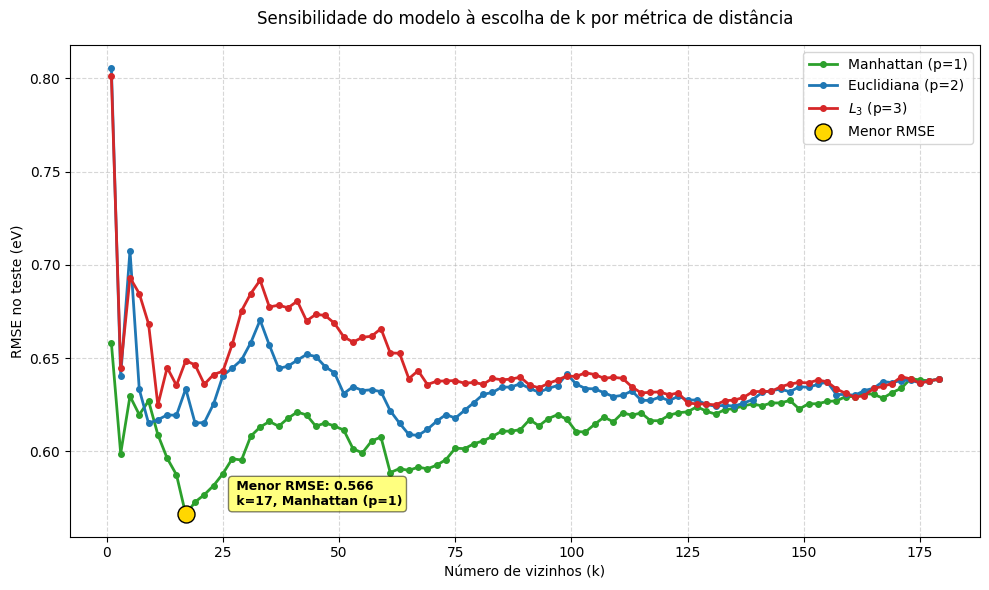

In [87]:
k_vizinhos = [k for k in range(1, 180) if k % 2 != 0]
metricas = [
    {"p": 1, "nome": "Manhattan (p=1)", "cor": "#2ca02c"}, 
    {"p": 2, "nome": "Euclidiana (p=2)", "cor": "#1f77b4"},
    {"p": 3, "nome": "$L_3$ (p=3)", "cor": "#d62728"}   
]

resultados_completos = []

menor_rmse_global = float("inf")
melhor_k_global = None
melhor_metrica_global = None

for metrica in metricas:
    rmses_metrica = []
    
    for k in k_vizinhos:
        knn = KNeighborsRegressor(n_neighbors=k, p=metrica["p"])
        
        knn.fit(X_treino, y_treino.values.ravel())
        y_pred = knn.predict(X_teste)
        
        rmse = root_mean_squared_error(y_teste, y_pred)
        rmses_metrica.append(rmse)

        if rmse < menor_rmse_global:
            menor_rmse_global = rmse
            melhor_k_global = k
            melhor_metrica_global = metrica["nome"]
        
    resultados_completos.append({
        "nome": metrica["nome"],
        "cor": metrica["cor"],
        "rmses": rmses_metrica
    })

fig, ax = plt.subplots(figsize=(10, 6))

for resultado in resultados_completos:
    ax.plot(
        k_vizinhos, 
        resultado["rmses"], 
        label=resultado["nome"], 
        color=resultado["cor"],
        linewidth=2,
        marker='o',
        markersize=4
    )

ax.scatter(
    melhor_k_global,
    menor_rmse_global,
    color="gold",
    edgecolor="black",
    s=150,
    zorder=5,
    label=f"Menor RMSE",
)

ax.annotate(
    f" Menor RMSE: {menor_rmse_global:.3f}\n k={melhor_k_global}, {melhor_metrica_global}",
    xy=(melhor_k_global, menor_rmse_global),
    xytext=(melhor_k_global + 10, menor_rmse_global + 0.005),
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5),
)

ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("RMSE no teste (eV)")
ax.set_title("Sensibilidade do modelo à escolha de k por métrica de distância", pad=15)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

Esse gráfico amplia nossa análise e demonstra que o melhor conjunto de hiperparâmetros para esse modelo é $k = 17$ com métrica de Manhattan.

Em um gráfico comparativo de y previsto por y verdadeiro, temos para esse hiperparâmetro:

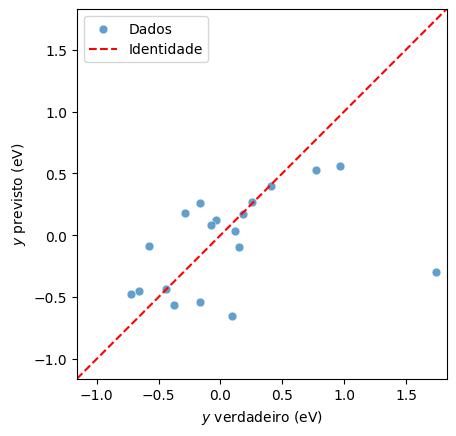

In [86]:
melhor_knn = KNeighborsRegressor(n_neighbors=17, p=1)
melhor_knn.fit(X_treino, y_treino.values.ravel())

melhor_y_previsto = melhor_knn.predict(X_teste).ravel()
y_real_1d = y_teste.values.ravel()

eixo = sns.scatterplot(x=y_real_1d, y=melhor_y_previsto, label="Dados", alpha=0.7, s=40)
eixo.plot(intervalo, intervalo, "r--", label="Identidade", linewidth=1.5)

eixo.set(
    xlabel="$y$ verdadeiro (eV)",
    ylabel="$y$ previsto (eV)",
    xlim=intervalo,
    ylim=intervalo,
    aspect="equal",
)
eixo.legend();

Aqui observamos uma concentração dos pontos ao longo da linha de identidade, com destaque para a região central ([-0.5, 0.5]), o que demonstra um ajuste preciso e consistente para a maioria das amostras.

A combinação da norma de Manhattan com uma vizinhança mais ampla ($k = 17$) reduziu a variância e eliminou oscilações bruscas decorrentes de ruídos locais. Por outro lado, o aumento do número de vizinhos impõe um efeito de suavização em valores extremos: para a amostra com y verdadeiro $= 1.75\text{ eV}$, o modelo realiza uma estimativa próxima a $-0.3\text{ eV}$, puxando a previsão em direção à média local. Apesar dessa limitação pontual em amostras periféricas, essa configuração garante a menor taxa de erro global $RMSE = 0.566\text{ eV}$, consolidando-se como a melhor solução para o problema.

Nas duas próximas seções, analisaremos o impacto da variação dos hiperparâmetros no desempenho do modelo quando mantemos um deles fixo.

<h3>Variação do número de vizinhos</h3>

Vamos agora fazer uma análise cuidadosa, avaliando o impacto da variação do número de vizinhos no desempenho do modelo.

Fixemos a métrica da distância, por exemplo, em $p = 2$ (Euclidiana). 

Para mapear todo o comportamento do algoritmo, vamos variar o valor de $k$ desde $k = 1$ até o limite de $k = 179$ vizinhos, uma vez que o  conjunto total apresenta $180$ exemplos.

In [40]:
import numpy as np

k_valores = list(range(1, 180))
rmse_treino = []
rmse_teste = []

y_tr_1d = y_treino.values.ravel()
y_te_1d = y_teste.values.ravel()

for k in k_valores:
    knn = KNeighborsRegressor(n_neighbors=k, p=2)
    knn.fit(X_treino, y_tr_1d)

    y_pred_tr = knn.predict(X_treino)
    rmse_tr = root_mean_squared_error(y_tr_1d, y_pred_tr)
    rmse_treino.append(rmse_tr)

    y_pred_te = knn.predict(X_teste)
    rmse_te = root_mean_squared_error(y_te_1d, y_pred_te)
    rmse_teste.append(rmse_te)

melhor_k = k_valores[np.argmin(rmse_teste)]
menor_rmse = min(rmse_teste)

print(f"O melhor k para esse modelo é de {melhor_k} vizinhos, gerando RMSE de{menor_rmse: .3f} eV.")

O melhor k para esse modelo é de 2 vizinhos, gerando RMSE de 0.569 eV.


Observamos graficamente, por meio das curvas de RMSE para os conjuntos de treino e teste:

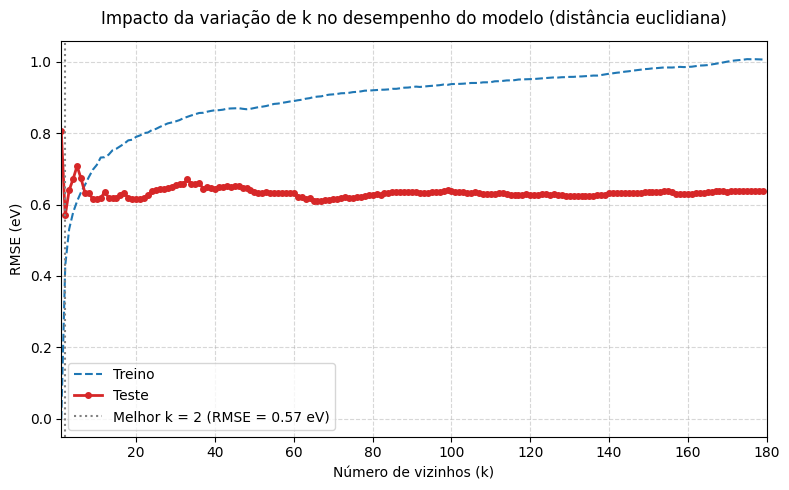

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_valores, rmse_treino, label="Treino", color="tab:blue", linestyle="--"
)
ax.plot(
    k_valores,
    rmse_teste,
    label="Teste",
    color="tab:red",
    linewidth=2,
    marker="o",
    markersize=4,
)

ax.axvline(
    x=melhor_k,
    color="gray",
    linestyle=":",
    label=f"Melhor k = {melhor_k} (RMSE = {menor_rmse:.2f} eV)",
)

ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("RMSE (eV)")
ax.set_title(
    "Impacto da variação de k no desempenho do modelo (distância euclidiana)",
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_xlim(left=1, right=180)

plt.tight_layout()
plt.show()

Analisando a curva, percebe-se bem as fases de comportamento do modelo:

- Em $k = 1$, observa-se erro de teste elevado ($RMSE \approx 0.81$) e erro de treino nulo ($RMSE = 0.0$), indicando overfitting, ou seja, baixo viés, mas alta variância.

- Em $k = 2$, apresenta-se o menor erro absoluto de teste ($RMSE = 0.57$). Por ser uma vizinhança muito pequena, o ponto é instável e suscetível à alta variância, podendo refletir apenas sorte na divisão dos dados.

- No intervalo de $k = 3$ a $k = 5$, é perceptível que o erro de teste salta até um pico em $k = 5$ ($RMSE \approx 0.71$), confirmando a instabilidade e a alta variância características de valores pequenos de $k$.

- No intervalo de $k = 6$ a $k = 15$, observa-se a queda do pico anterior, atingindo a zona ótima do modelo entre $k = 7$ e $k = 15$ ($RMSE \approx 0.62$). Essa faixa apresenta o melhor equilíbrio entre viés e variância, garantindo estabilidade e precisão local.

- Na faixa de $k = 16$ a $k = 30$, o erro de teste sofre uma leve elevação ($RMSE \approx 0.64$ a $0.66$). O modelo ganha um pouco mais de viés e mantém a estabilidade, mas começa a perder suavemente a resolução dos padrões locais.

- Por fim, entre $k = 31$ e $k = 179$,  as curvas se aproximam e o erro de teste estagna em $RMSE \approx 0.63$. Nesse caso, ocorre undefitting, ou seja, há alto viés e baixa variância e, como a vizinhança engloba praticamente todo o conjunto de dados, o $k$-NN apenas retorna a média global da base, perdendo o poder preditivo espacial.

A partir disso, pode-se concluir que o intervalo ideal de operação do modelo é com $k$ variando de $k = 7$ a $k = 15$.

Mas isso não é o bastante para confirmarmos que esse é o melhor intervalo de $k$. Para ter certeza, precisamos utilizar um método denominado Validação Cruzada [x], uma técnica que avalia a generalização do modelo dividindo a base de dados em $V$ subamostras (dobras). O algoritmo é treinado $V$ vezes, utilizando em cada rodada $V-1$ dobras para treino e a dobra restante para teste, permitindo para esse caso que a configuração ideal de número $k$ de vizinhos seja escolhida com base no menor erro médio global, sem depender da sorte de uma única divisão dos dados.

É isso que faremos agora. O conjunto de treino original conta com 180 amostras; adotemos $V = 5$ dobras. A validação cruzada divide os dados em blocos onde $80\%$ da base é usada para ajuste e $20\%$ é reservada para validação a cada rodada. Por essa razão, a busca por $k$ estende-se com segurança até o limite operacional de $144$ vizinhos (quantidade máxima disponível na etapa de treino de cada dobra).

Abaixo, a tabela exibe as cinco melhores configurações de $k$ obtidas após a avaliação global em todas as dobras:

In [88]:
from sklearn.model_selection import cross_val_score

cv_folds = 5
n_amostras_treino = len(X_treino)

max_k_possivel = int(n_amostras_treino * (cv_folds - 1) / cv_folds)

k_valores = range(1, max_k_possivel + 1)

resultados_cv = []

for k in k_valores:
    knn = KNeighborsRegressor(n_neighbors=k, p=2)

    scores = cross_val_score(
        knn,
        X_treino,
        y_treino.values.ravel() if hasattr(y_treino, "values") else y_treino,
        scoring="neg_root_mean_squared_error",
        cv=cv_folds,
    )

    rmse_por_fold = -scores

    resultados_cv.append(
        {
            "k (vizinhos)": k,
            "RMSE médio (eV)": np.mean(rmse_por_fold),
            "Desvio padrão (eV)": np.std(rmse_por_fold), 
        }
    )

df_cv = pd.DataFrame(resultados_cv).sort_values(by="RMSE médio (eV)")

print(
    df_cv.head(10).to_string(
        index=False,
        justify="center",
        col_space=15,
        formatters={"RMSE médio (eV)": "{:.3f}".format, "Desvio padrão (eV)": "{:.3f}".format},
    )
)

  k (vizinhos)  RMSE médio (eV) Desvio padrão (eV)
        3            0.768            0.099       
        4            0.770            0.084       
        2            0.778            0.107       
        5            0.785            0.075       
        9            0.789            0.091       
        7            0.791            0.087       
        6            0.793            0.089       
       10            0.800            0.087       
        8            0.800            0.096       
       11            0.809            0.088       


Verificamos nessa tabela que $k = 3$ foi o valor de $k$ que obteve o menor RMSE médio, de $0.768 \text{ eV}$!

Esse resultado parece contrariar a análise anterior; contudo, essa divergência é esperada, uma vez que, com a validação cruzada, a avaliação passa a ser realizada sobre 5 dobras distintas (folds) em vez de uma única divisão estática entre treino e teste. Com isso, o menor erro obtido anteriormente em $k = 2$ (de $0.57 \text{ eV}$) revelou-se um viés daquela amostragem específica, enquanto a validação cruzada expôs a alta variabilidade associada a valores muito baixos de $k$. Além disso, como cada iteração da validação cruzada treina o modelo com apenas 80% dos dados (144 amostras), a métrica média torna-se mais rigorosa e realista quanto à capacidade de generalização do algoritmo.

Entretanto, a escolha do modelo ideal não deve se restringir apenas à minimização do erro médio, devendo também considerar a sua variabilidade. Para isso, vamos reordenar os resultados pelo desvio padrão:

In [63]:
df_estabilidade = df_cv[
    ["k (vizinhos)", "Desvio padrão (eV)", "RMSE médio (eV)"]
].sort_values(by="Desvio padrão (eV)")

print(
    df_estabilidade.head(10).to_string(
        index=False,
        justify="center",
        col_space=15,
        formatters={
            "RMSE médio (eV)": "{:.4f}".format,
            "Desvio padrão (eV)": "{:.4f}".format,
        },
    )
)

  k (vizinhos)  Desvio padrão (eV) RMSE médio (eV)
        5             0.0746            0.7845    
      144             0.0806            1.0064    
      143             0.0820            1.0064    
      142             0.0832            1.0069    
        4             0.0839            0.7705    
      141             0.0845            1.0068    
      139             0.0847            1.0047    
       13             0.0848            0.8187    
      140             0.0849            1.0067    
      100             0.0851            0.9540    


A reordenação dos resultados pelo desvio padrão revela que o valor de $k = 5$ atinge a maior estabilidade entre as dobras da validação cruzada, apresentando o menor valor de desvio padrão ($0.0746 \text{ eV}$).

Ao comparar esse resultado com o ponto de menor erro médio absoluto ($k = 3$, com $\text{RMSE} = 0.768 \text{ eV}$), é possível observar que migrar de $k = 3$ para $k = 5$ acarreta um aumento de apenas $0.0165 \text{ eV}$ no RMSE médio, enquanto proporciona uma redução expressiva de cerca de $24\%$ na variabilidade das predições. 

É importante destacar também que, embora valores altíssimos de $k$ (como $k = 144$) apresentem desvios padrões baixos, eles introduzem um viés muito grande e degradam a precisão do modelo, elevando o erro para patamares superiores a $1.00 \text{ eV}$ devido ao subajuste (underfitting).

Graficamente, podemos visualizar esse balanço entre desvio padrão e RMSE, utilizando técnica de análise da fronteira de eficiência. que mapeia a busca por hiperparâmetros em um espaço bidimensional, projetando o desvio padrão da validação cruzada no eixo X (estabilidade) e o RMSE médio no eixo Y (precisão). Nesse caso, a região ideal de operação está presente no canto inferior esquerdo (local que minimiza ambos os eixos simultaneamente), utilizando uma escala de cores para representar a variação contínua do parâmetro $k$ e isolando visualmente o ponto de equilíbrio perfeito, demonstrando a transição entre o menor RMSE em $k = 3$ e o menor desvio padrão em $k = 5$.

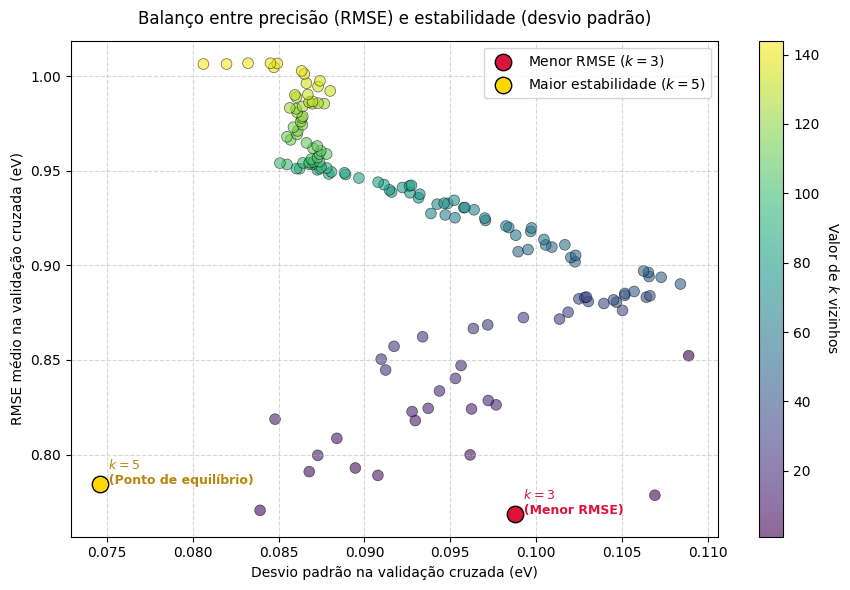

In [77]:
df_cv.columns = ["k (vizinhos)", "RMSE médio", "Desvio padrão"]

idx_min_rmse = df_cv["RMSE médio"].idxmin()
k_min_rmse = int(df_cv.loc[idx_min_rmse, "k (vizinhos)"])
rmse_min_rmse = df_cv.loc[idx_min_rmse, "RMSE médio"]
std_min_rmse = df_cv.loc[idx_min_rmse, "Desvio padrão"]

idx_min_std = df_cv["Desvio padrão"].idxmin()
k_min_std = int(df_cv.loc[idx_min_std, "k (vizinhos)"])
rmse_min_std = df_cv.loc[idx_min_std, "RMSE médio"]
std_min_std = df_cv.loc[idx_min_std, "Desvio padrão"]

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df_cv["Desvio padrão"],
    df_cv["RMSE médio"],
    c=df_cv["k (vizinhos)"],
    cmap="viridis",
    s=60,
    alpha=0.6,
    edgecolor="k",
    linewidth=0.5,
)

cbar = plt.colorbar(scatter)
cbar.set_label("Valor de $k$ vizinhos", rotation=270, labelpad=15)

# k=3
ax.scatter(
    std_min_rmse,
    rmse_min_rmse,
    color="crimson",
    s=140,
    edgecolor="black",
    zorder=5,
    label=f"Menor RMSE ($k={k_min_rmse}$)",
)
ax.annotate(
    f"  $k={k_min_rmse}$\n  (Menor RMSE)",
    (std_min_rmse, rmse_min_rmse),
    fontsize=9,
    weight="bold",
    color="crimson",
)

#k=5
ax.scatter(
    std_min_std,
    rmse_min_std,
    color="gold",
    s=140,
    edgecolor="black",
    zorder=5,
    label=f"Maior estabilidade ($k={k_min_std}$)",
)
ax.annotate(
    f"  $k={k_min_std}$\n  (Ponto de equilíbrio)",
    (std_min_std, rmse_min_std),
    fontsize=9,
    weight="bold",
    color="darkgoldenrod",
)

ax.set_xlabel("Desvio padrão na validação cruzada (eV)")
ax.set_ylabel("RMSE médio na validação cruzada (eV)")
ax.set_title(
    "Balanço entre precisão (RMSE) e estabilidade (desvio padrão)",
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

Analisando o gráfico, percebe-se que valores muito altos de $k$ (tons amarelos no topo) degradam a precisão devido ao underfitting, mantendo o erro acima de $0.95 \text{ eV}$. No outro extremo, $k = 3$ (ponto vermelho) garante o menor erro do modelo ($\text{RMSE} \approx 0.768 \text{ eV}$), porém sofre com maior instabilidade entre os folds, apresentando desvio padrão de aproximadamente $0.099 \text{ eV}$. 

O ponto em amarelo, $k = 5$, destaca o melhor ponto de operação por ocupar a região mais à esquerda e próxima do canto inferior esquerdo. Essa posição comprova que a escolha por $k = 5$ maximiza a estabilidade do modelo (Desvio Padrão $\approx 0.075 \text{ eV}$) ao custo de um aumento muito pequeno no RMSE médio.

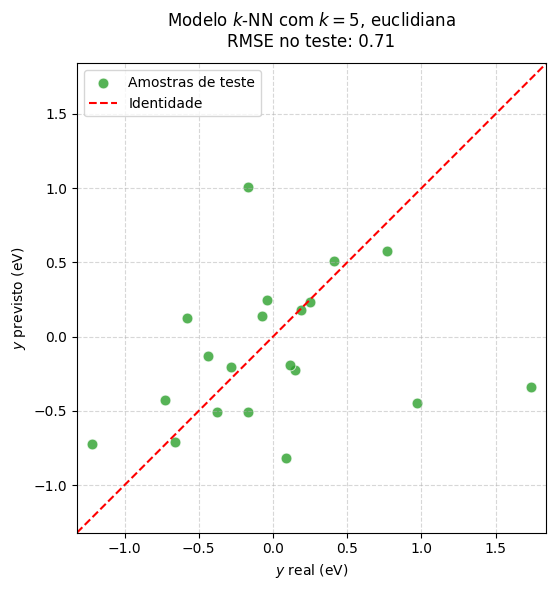

In [85]:
knn_k5 = KNeighborsRegressor(n_neighbors=5, p=2)
knn_k5.fit(X_treino, y_treino.values.ravel())

y_pred_k5 = knn_k5.predict(X_teste).ravel()
y_real = y_teste.values.ravel()
rmse_k5_teste = root_mean_squared_error(y_real, y_pred_k5)

fig, ax = plt.subplots(figsize=(6, 6))

# Limites para a linha diagonal perfeita
lim_min = min(min(y_real), min(y_pred_k5)) - 0.1
lim_max = max(max(y_real), max(y_pred_k5)) + 0.1

sns.scatterplot(
    x=y_real,
    y=y_pred_k5,
    color="#2ca02c",
    label="Amostras de teste",
    alpha=0.8,
    s=60,
    ax=ax,
)
ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    "r--",
    linewidth=1.5,
    label="Identidade",
)

ax.set_xlabel("$y$ real (eV)")
ax.set_ylabel("$y$ previsto (eV)")
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect("equal")

ax.set_title(
    f"Modelo $k$-NN com $k=5$, euclidiana\nRMSE no teste: {rmse_k5_teste:.2f}",
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

O gráfico confirma a boa capacidade de generalização do modelo no conjunto de teste, resultando em um $\text{RMSE} = 0.71\text{ eV}$.

A concentração dos pontos ao redor da linha de identidade indica alta precisão na faixa central. A dispersão observada nos valores extremos (como em $y \approx 1.75\text{ eV}$) reflete uma limitação do $k$-NN: por prever com base na média dos $5$ vizinhos mais próximos, o algoritmo tende a suavizar estimativas nas bordas do conjunto de dados, subestimando valores muito altos ou sobreestimando os muito baixos.

Portanto, variando o número $k$ de vizinhos e mantendo fixa a métrica (Euclidiana, $p=2$), concluimos que o número $k$ que resulta no melhor desempenho para nosso modelo é $k = 5$. 

<h3>Variação da métrica de distância</h3>

Agora vamos analisar o impacto da mudança da métrica de distância no desempenho do modelo.

Mantendo o número k de vizinhos com $k = 5$, que foi o melhor $k$ encontrado na seção anterior, vamos variar a métrica de distância entre Manhattan ($p = 1$), Euclidiana ($p = 2$) e $L_3$ ($p = 3$).

A tabela e o gráfico a seguir apresentam os valores do erro quadrático médio (RMSE) obtidos para cada uma das métricas analisadas:

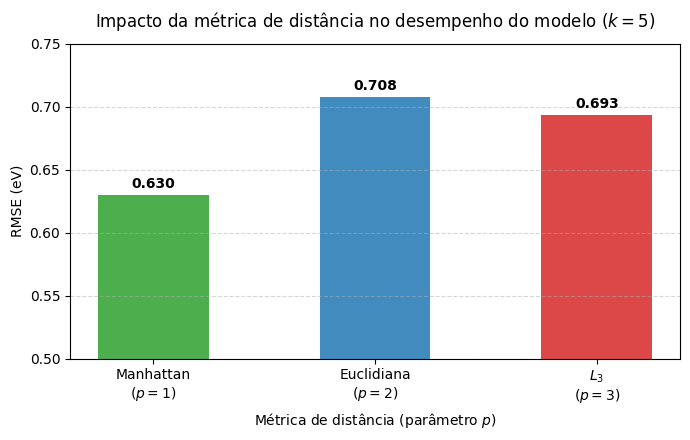

In [122]:
metricas = [
    {"p": 1, "rótulo": "Manhattan\n($p=1$)"},
    {"p": 2, "rótulo": "Euclidiana\n($p=2$)"},
    {"p": 3, "rótulo": "$L_3$\n($p=3$)"},
]

y_treino_flat = y_treino.values.ravel()
y_teste_flat = y_teste.values.ravel()

metricas_nomes = []
rmses = []

for m in metricas:
    knn = KNeighborsRegressor(n_neighbors=5, p=m["p"])
    knn.fit(X_treino, y_treino_flat)

    y_prev = knn.predict(X_teste)
    rmse = root_mean_squared_error(y_teste_flat, y_prev)

    metricas_nomes.append(m["rótulo"])
    rmses.append(rmse)

fig, ax = plt.subplots(figsize=(7, 4.5))

cores = ["#2ca02c", "#1f77b4", "#d62728"]
barras = ax.bar(metricas_nomes, rmses, color=cores, width=0.5, alpha=0.85)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(
        f"{altura:.3f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylim(0.5, 0.75)
ax.set_ylabel("RMSE (eV)")
ax.set_xlabel("Métrica de distância (parâmetro $p$)")
ax.set_title("Impacto da métrica de distância no desempenho do modelo ($k = 5$)", pad=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

O gráfico mostra que a métrica de distância Manhattan é a que obteve o menor erro quadrático médio no conjunto de teste ($RMSE = 0.630\text{ eV}$). Isso pode ser justificado pela natureza geométrica dos dados de entrada. Por somar apenas as diferenças absolutas em escala linear, a norma $p=1$ evita que desvios pontuais desproporcionais distorçam o cálculo de proximidade, garantindo maior estabilidade frente a outliers.

A transição para a norma Euclidiana ($p=2$) provocou a maior degradação de desempenho ($RMSE = 0.708\text{ eV}$). A elevação dos desvios ao quadrado acumula pequenos ruídos presentes em múltiplas dimensões, o que polui a métrica e induz à seleção de vizinhos menos representativos. 

Curiosamente, a métrica $L_3$ ($p = 3$) apresentou uma recuperação parcial da precisão ($RMSE = 0.693\text{ eV}$) em relação à Euclidiana. Isso ocorreu pois, à medida que $p$ cresce, a distância passa a ser dominada pela maior divergência isolada entre os atributos, atenuando o peso do ruído secundário das demais variáveis, embora ainda permaneça inferior à simplicidade e consistência da norma Manhattan.

Para ampliar nossa análise em relação ao motivo de a distância Manhattan ser a com melhor desempenho, vamos fazer um gráfico box-plot que apresente as três métricas:

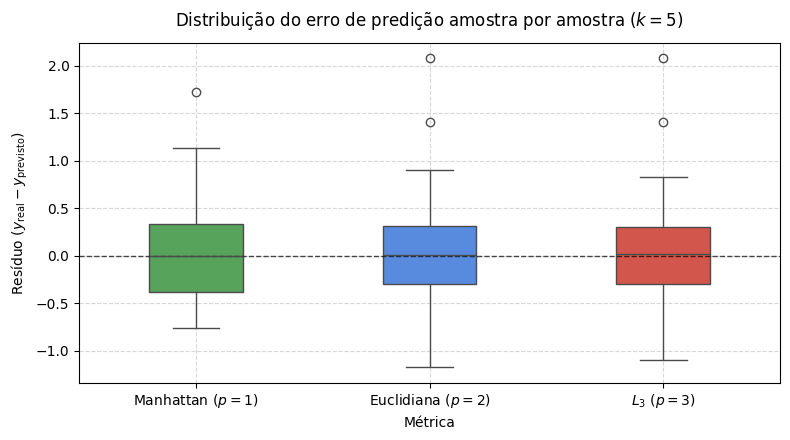

In [127]:
residuos_lista = []
metricas_info = [
    {"p": 1, "nome": "Manhattan ($p=1$)"},
    {"p": 2, "nome": "Euclidiana ($p=2$)"},
    {"p": 3, "nome": "$L_3$ ($p=3$)"},
]

for m in metricas_info:
    knn = KNeighborsRegressor(n_neighbors=5, p=m["p"])
    knn.fit(X_treino, y_treino.values.ravel())
    y_pred = knn.predict(X_teste).ravel()
    erros_individuais = y_teste.values.ravel() - y_pred

    for erro in erros_individuais:
        residuos_lista.append({"Métrica": m["nome"], "Resíduo": erro})

df_residuos = pd.DataFrame(residuos_lista)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    x="Métrica",
    y="Resíduo",
    data=df_residuos,
    hue = "Métrica",
    palette=["#4CAF50", "#4285F4", "#EA4335"],
    legend = False,
    width=0.4,
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_ylabel("Resíduo ($y_{\\text{real}} - y_{\\text{previsto}}$)")
ax.set_title("Distribuição do erro de predição amostra por amostra ($k = 5$)", pad=12)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

E o gráfico realmente confirma visualmente o motivo de a métrica Manhattan ser a melhor para esse modelo!

Embora todas as três métricas apresentem medianas próximas de $0$, indicando a ausência de viés sistemático de predição, a norma Manhattan ($p=1$) exibe limites inferiores mais contidos e um único outlier superior bem menos severo (próximo a $1.7\text{ eV}$). Em contrapartida, as métricas Euclidiana ($p = 2$) e $L_3$ ($p = 3$) apresentam dispersões negativas mais acentuadas (atingindo erros abaixo de $-1.0\text{ eV}$) e desvios extremos superiores que ultrapassam $2.0\text{ eV}$. Como métricas de avaliação como o RMSE elevam os resíduos ao quadrado, esses outliers mais distantes penalizam fortemente o desempenho geral das normas $p=2$ e $p=3$.

Portanto, variando a métrica e mantendo fixo o número de vizinhos ($k=5$), conclui-se que a distância Manhattan ($p=1$) é a que proporciona o melhor desempenho, garantindo maior estabilidade e menor dispersão de erros extremos no modelo.

<h2>Conclusões e principais aprendizados </h2>

<h2>Descrição do uso de IA neste trabalho</h2>


<h2>Referências bibliográficas</h2>


https://www.kaggle.com/datasets/allanwandia/material-science

https://www.ibm.com/think/topics/distance-metrics

https://www.ibm.com/docs/pt-br/spss-modeler/19.0.0?topic=settings-cross-validation